<a href="https://colab.research.google.com/github/deshmukhvaishnavi04/celebal-internship/blob/main/Week3_vaishnavi_deshmukh_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#### Customer Intelligence System using Classification, Ensemble Learning & Clustering




In [1]:
from google.colab import files

uploaded = files.upload()

Saving Country-data.csv to Country-data.csv
Saving data-dictionary.csv to data-dictionary.csv


###Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

###Load Dataset

In [3]:
df = pd.read_csv("Country-data.csv")
dictionary = pd.read_csv("data-dictionary.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
dictionary.head()

,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...


###Dataset Overview

In [5]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [6]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(167, 10)


In [7]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


In [8]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [9]:
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


###Missing Values & Duplicates

In [10]:
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

Missing Values
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate Rows
0


###Income Distribution  Analysis

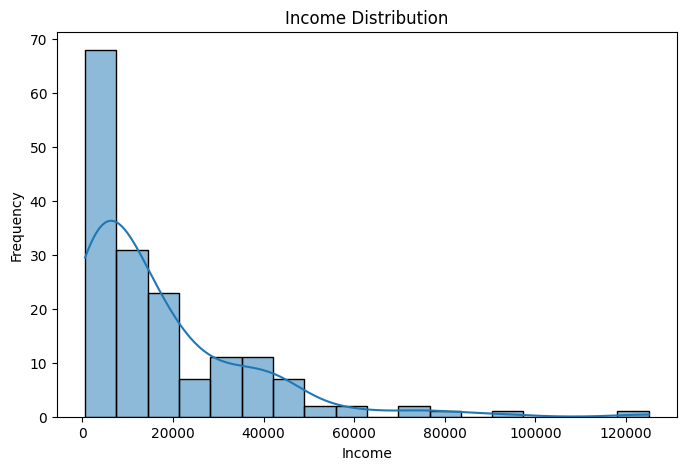

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["income"],
    kde=True
)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

###Life Expectancy Distribution


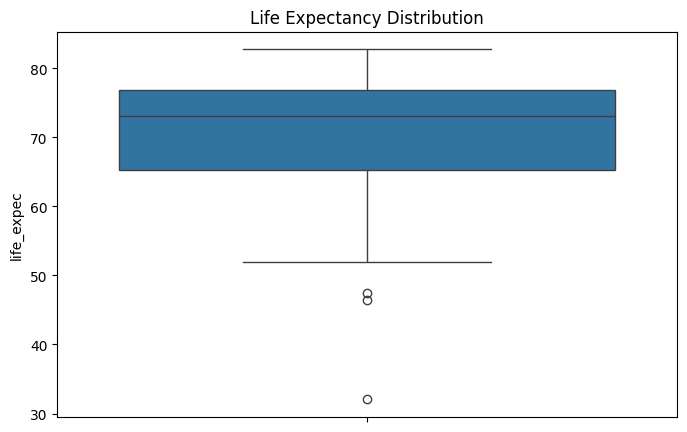

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df["life_expec"]
)

plt.title("Life Expectancy Distribution")

plt.show()

###Correlation Heatmap

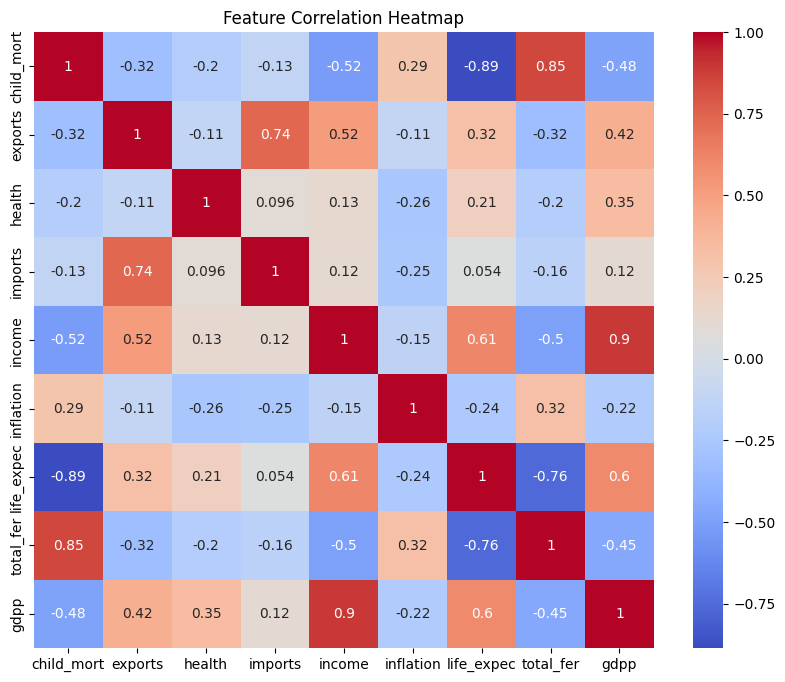

In [13]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop("country",axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

###Feature Scaling

In [14]:
from sklearn.preprocessing import StandardScaler

X = df.drop("country",axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

###PCA

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

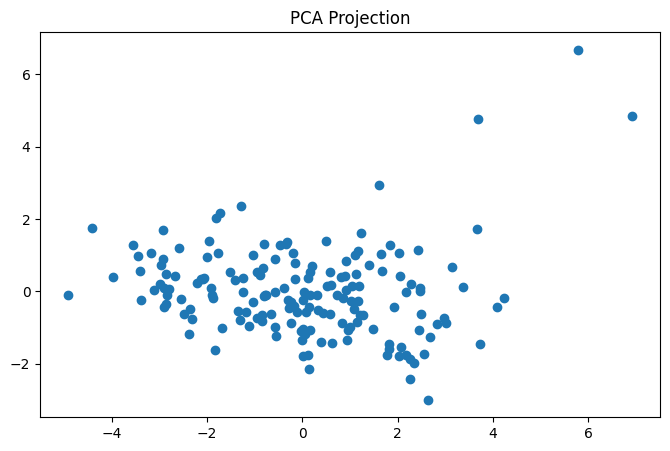

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

plt.title("PCA Projection")

plt.show()

###K-Means Clustering

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

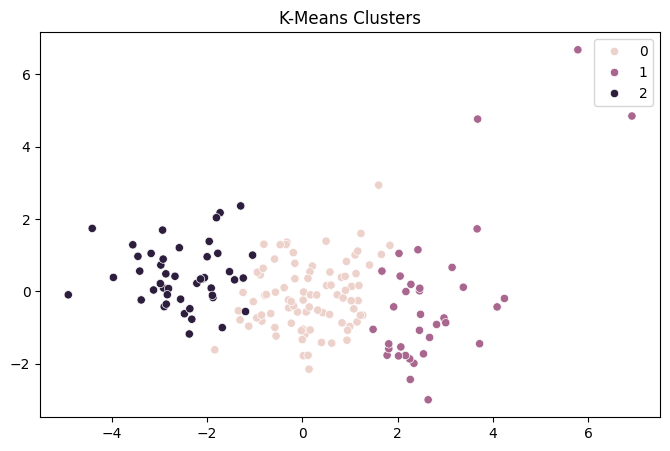

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters
)

plt.title("K-Means Clusters")

plt.show()

###DBSCAN Clustering

In [19]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_clusters = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_clusters

###Cluster Profiling

In [20]:
cluster_profile = df.groupby(
    "Cluster"
).mean(
    numeric_only=True
)

display(cluster_profile)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
Cluster,,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442,-0.069767
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111,-0.333333


###Create Target Variable

In [21]:
df["Target"] = df["Cluster"]

###Train-Test Split

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop(
    ["country","Cluster","DBSCAN_Cluster","Target"],
    axis=1
)

y = df["Target"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

###Random Forest Classification

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test,rf_pred)
)

Accuracy: 1.0


###XGBoost Classification

In [24]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42
)

xgb.fit(X_train,y_train)

xgb_pred = xgb.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test,xgb_pred)
)

Accuracy: 1.0


###Model Comparison

In [25]:
comparison = pd.DataFrame({
    "Model":["Random Forest","XGBoost"],
    "Accuracy":[
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred)
    ]
})

comparison

,Model,Accuracy
0,Random Forest,1.0
1,XGBoost,1.0


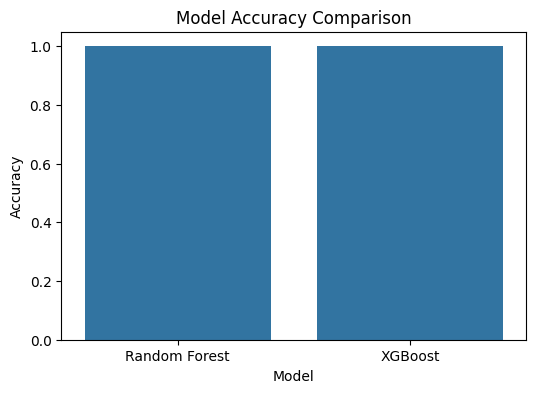

In [26]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.show()

###Feature Importance Analysis

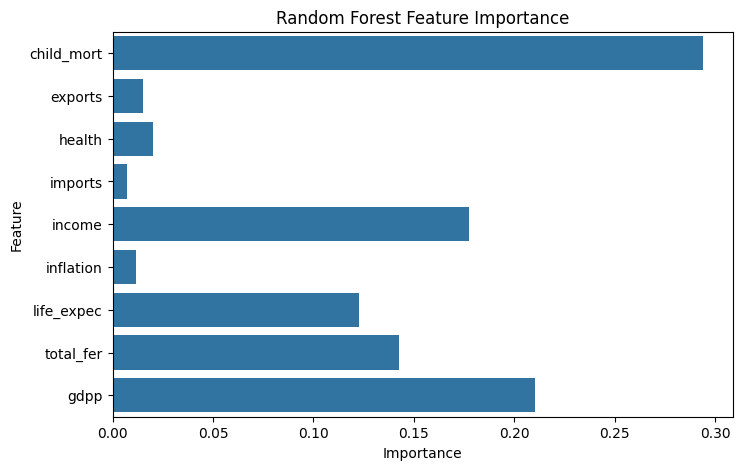

In [27]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.show()

###Conclusion

This project successfully developed a Customer Intelligence System using clustering, classification, and ensemble learning techniques. K-Means and DBSCAN segmented countries into meaningful groups based on socio-economic indicators. Random Forest and XGBoost accurately predicted cluster membership, while feature importance analysis identified the most influential factors driving segmentation. Overall, the project provides valuable customer intelligence for data-driven decision making.